In [76]:
from Bio import SeqIO
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re

In [77]:
def prepare_segment_dataset(df_path, fasta_path):

    df = pd.read_csv(df_path)
    
    seq_dict = {r.id: str(r.seq) for r in SeqIO.parse(fasta_path, 'fasta')}
    
    df['Sequence'] = df['Accession'].map(seq_dict)

    unmatched_rows = df[df['Sequence'].isna()]
    
    if not unmatched_rows.empty:
        print(f'Upozorenje: Pronađeno je {len(unmatched_rows)} Accession brojeva koji NISU pronađeni u FASTA fajlu:')
        print(unmatched_rows['Accession'].tolist())
    else:
        print('Svi Accession brojevi su uspešno upareni sa FASTA fajlom!')
    
    df = df.dropna(subset=['Sequence'])
    
    df['Sequence'] = df['Sequence'].str.upper()
    ambiguous_pattern = '[^ACGT]'
    
    df_clean = df[~df['Sequence'].str.contains(ambiguous_pattern, regex=True)].copy()

    ambiguous_rows = df[df['Sequence'].str.contains(ambiguous_pattern, regex=True)].copy()

    def get_ambiguous_chars(seq):
        return set(re.findall(ambiguous_pattern, seq))

    ambiguous_rows['Found_Ambiguous'] = ambiguous_rows['Sequence'].apply(get_ambiguous_chars)

    print(ambiguous_rows[['Accession', 'Found_Ambiguous']])
    
    print(f'Originalni broj redova: {len(df)}')
    print(f'Broj redova nakon čišćenja: {len(df_clean)}')
    
    return df_clean

In [78]:
hantaan_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/hantaan_all.csv','../data/raw/hantaan.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
       Accession        Found_Ambiguous
87    PV848112.1                    {W}
181   OR684711.1  {M, R, W, K, S, H, Y}
388   OR239914.1                    {W}
660   MW349028.1                    {R}
896   MN608072.1                    {Y}
1056  MK189292.1                    {M}
1062  MK189298.1                    {R}
1137  MF141748.1                    {M}
1241  KY283955.1                 {Y, R}
1242  KY283956.1                    {R}
1264  KY357322.1                    {Y}
1404  KT934997.1                    {R}
1871  FJ844392.1                 {Y, R}
1985  EU092222.1                    {R}
2000  EF208930.1                 {M, R}
2069  AF288658.1           {M, S, R, Y}
2090  AB071183.1                 {R, Y}
2093  AB071186.1                    {Y}
2181  AF172424.1                    {Y}
Originalni broj redova: 2218
Broj redova nakon čišćenja: 2199


In [79]:
puumala_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/puumala_all.csv','../data/raw/puumala.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
       Accession Found_Ambiguous
6     PQ867783.1             {R}
119   OR573657.1             {R}
121   OR581028.1             {R}
344   OP561828.1          {W, Y}
365   OP561849.1          {W, Y}
433   MZ580953.1             {S}
577   MZ014471.1             {R}
578   MZ014472.1             {R}
579   MZ014473.1             {R}
868   MZ343346.1          {R, V}
879   MZ343357.1             {R}
976   MW023667.1             {Y}
979   MW023670.1             {R}
987   MW023678.1             {R}
1012  MW023703.1             {Y}
1025  MW023716.1             {R}
1029  MW023720.1             {R}
1033  MW023724.1             {Y}
1036  MW023727.1          {Y, R}
1568  MN026221.1             {W}
1583  MN026236.1             {Y}
1600  MN026253.1             {K}
1616  MK770463.1          {R, K}
1621  MK770468.1             {R}
1623  MK770470.1             {M}
1630  MK770477.1          {S, Y}
1632  MK770479.1             {R}
1635  MK770482.1  

In [80]:
dobrava_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/dobrava_all.csv','../data/raw/dobrava_belgrade.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
      Accession Found_Ambiguous
4    PX840724.1             {Y}
127  MK770453.1             {Y}
177  KY649165.1       {W, R, Y}
431  KJ437511.1             {R}
515  JQ026206.1       {Y, R, K}
576  GQ205409.1             {R}
695  AY961616.1             {R}
717  AY168576.1    {M, R, Y, K}
724  AJ269549.1    {M, R, Y, K}
725  AJ269550.1    {M, R, Y, K}
Originalni broj redova: 781
Broj redova nakon čišćenja: 771


In [81]:
sin_nombre_dataset = prepare_segment_dataset('../data/processed_sequences/all_sequences/sin_nombre_all.csv','../data/raw/sin_nombre.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession     Found_Ambiguous
9   PX401025.1                 {M}
19  OQ999111.1                 {M}
45  OQ999151.1              {S, K}
69  ON571584.1              {S, V}
70  ON571587.1                 {S}
72  ON571591.1                 {W}
75  MZ400487.1  {M, R, W, K, S, Y}
76  MZ400488.1                 {Y}
Originalni broj redova: 366
Broj redova nakon čišćenja: 358


In [82]:
print(f'Hantaan: {len(hantaan_dataset)} sekvenci')
print(f'Dobrava: {len(dobrava_dataset)} sekvenci')
print(f'Puumala: {len(puumala_dataset)} sekvenci')
print(f'Sin Nombre: {len(sin_nombre_dataset)} sekvenci')

Hantaan: 2199 sekvenci
Dobrava: 771 sekvenci
Puumala: 3625 sekvenci
Sin Nombre: 358 sekvenci


In [83]:
all_sequences = pd.concat([
    hantaan_dataset,
    dobrava_dataset,
    puumala_dataset,
    sin_nombre_dataset
], ignore_index=True)

In [84]:
print(f'\nKonačan broj redova datasetu: {len(all_sequences)}')


Konačan broj redova datasetu: 6953


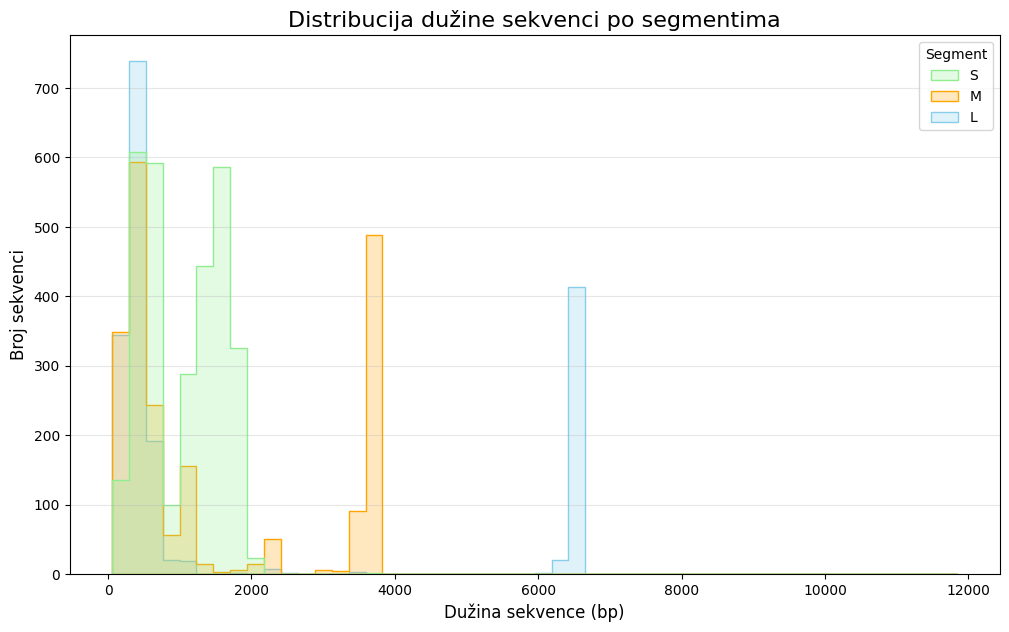

In [85]:
plt.figure(figsize=(12, 7))

sns.histplot(data=all_sequences, 
             x=all_sequences['Sequence'].str.len(), 
             hue='Segment', 
             bins=50, 
             kde=False,
             palette={'S': 'lightgreen', 'M': 'orange', 'L': 'skyblue'},
             element='step') 

plt.title('Distribucija dužine sekvenci po segmentima', fontsize=16)
plt.xlabel('Dužina sekvence (bp)', fontsize=12)
plt.ylabel('Broj sekvenci', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Kompletne sekvence

In [86]:
hantaan_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/hantaan_complete.csv','../data/raw/hantaan.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
      Accession Found_Ambiguous
243  EF208930.1          {M, R}
Originalni broj redova: 250
Broj redova nakon čišćenja: 249


In [87]:
puumala_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/puumala_complete.csv','../data/raw/puumala.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession Found_Ambiguous
6   OR573657.1             {R}
26  MZ014471.1             {R}
27  MZ014472.1             {R}
28  MZ014473.1             {R}
Originalni broj redova: 127
Broj redova nakon čišćenja: 123


In [88]:
dobrava_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/dobrava_complete.csv','../data/raw/dobrava_belgrade.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
     Accession Found_Ambiguous
23  JQ026206.1       {Y, R, K}
32  GQ205409.1             {R}
Originalni broj redova: 40
Broj redova nakon čišćenja: 38


In [89]:
sin_nombre_complete_dataset = prepare_segment_dataset('../data/processed_sequences/complete_sequences/sin_nombre_complete.csv','../data/raw/sin_nombre.fasta')

Svi Accession brojevi su uspešno upareni sa FASTA fajlom!
Empty DataFrame
Columns: [Accession, Found_Ambiguous]
Index: []
Originalni broj redova: 18
Broj redova nakon čišćenja: 18


In [90]:
print(f'Hantaan: {len(hantaan_complete_dataset)} sekvenci')
print(f'Dobrava: {len(dobrava_complete_dataset)} sekvenci')
print(f'Puumala: {len(puumala_complete_dataset)} sekvenci')
print(f'Sin Nombre: {len(sin_nombre_complete_dataset)} sekvenci')

Hantaan: 249 sekvenci
Dobrava: 38 sekvenci
Puumala: 123 sekvenci
Sin Nombre: 18 sekvenci


In [91]:
complete_sequences = pd.concat([
    hantaan_complete_dataset,
    dobrava_complete_dataset,
    puumala_complete_dataset,
    sin_nombre_complete_dataset
], ignore_index=True)

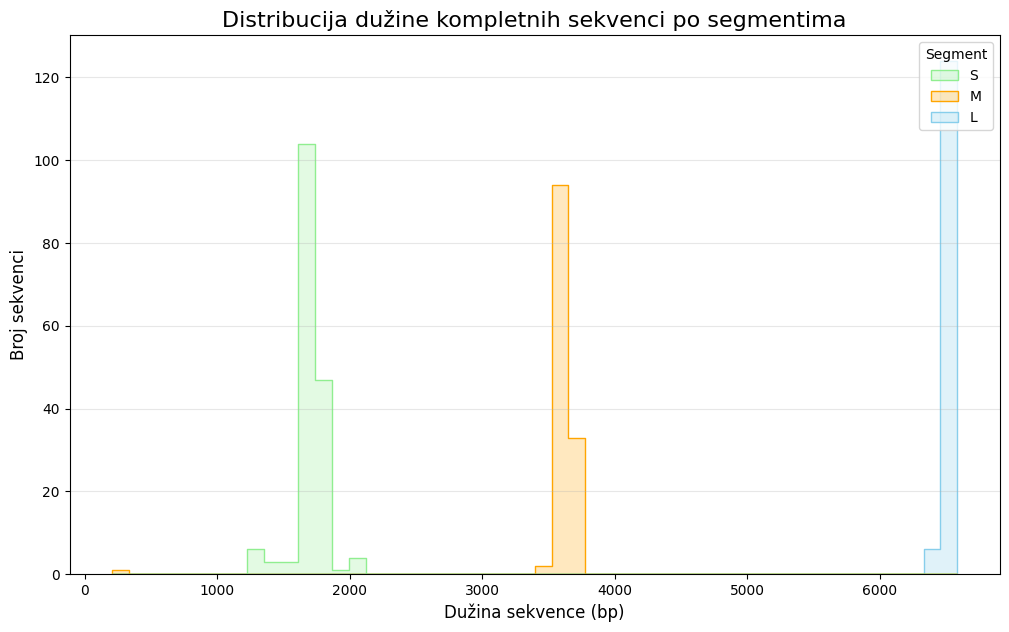

In [92]:
plt.figure(figsize=(12, 7))


sns.histplot(data=complete_sequences, 
             x=complete_sequences['Sequence'].str.len(), 
             hue='Segment', 
             bins=50, 
             kde=False,
             palette={'S': 'lightgreen', 'M': 'orange', 'L': 'skyblue'},
             element='step') 

plt.title('Distribucija dužine kompletnih sekvenci po segmentima', fontsize=16)
plt.xlabel('Dužina sekvence (bp)', fontsize=12)
plt.ylabel('Broj sekvenci', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [93]:
print(complete_sequences.groupby('Segment')['Sequence'].apply(lambda x: x.str.len().mean()))

Segment
L    6527.815385
M    3598.230769
S    1718.029762
Name: Sequence, dtype: float64


In [94]:
short = complete_sequences[(complete_sequences['Sequence'].str.len() < 1000)]

In [95]:
print(short)

     Unnamed: 0   Accession Segment Nuc_Completeness  \
263         171  KU561220.1       M         complete   

                         Species  \
263  Orthohantavirus dobravaense   

                                              Sequence  
263  ATTTGTCCTGCCCTCAGTCACAGTGTCCTTATTGTTTTACACATTG...  


In [96]:
complete_sequences = complete_sequences[~((complete_sequences['Accession'] == 'KU561220.1'))]

In [97]:
all_sequences.loc[all_sequences['Accession'] == 'KU561220.1', 'Nuc_Completeness'] = 'partial'

In [98]:
all_sequences.to_csv('../data/processed_sequences/final/all_sequences.csv')

In [99]:
complete_sequences.to_csv('../data/processed_sequences/final/complete_sequences.csv')